# Handling the missing or null values

In [56]:
# Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [57]:
# Load dataset
data=pd.read_csv("telecom_churn_data.csv")

In [58]:
# Basic check
data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,NaN,Electronic check,70.70,151.65,Yes


In [59]:
data.tail()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes
7042,3186-AJIEK,Male,0,No,No,66,Yes,No,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No


In [60]:
data.shape

(7043, 21)

In [61]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7038 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7041 non-null   object 


In [62]:
data.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7041.000000
mean,0.162147,32.371149,64.749581
std,0.368612,24.559481,30.085731
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


## Check for null or missing values

In [63]:
data.isnull().sum()

customerID          0
gender              5
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    2
PaymentMethod       0
MonthlyCharges      2
TotalCharges        5
Churn               0
dtype: int64

In [64]:
# Check its data type if object use mode
data.loc[:,'gender'].dtype

dtype('O')

In [65]:
data.loc[:,'gender'].mode()[0]

'Male'

In [66]:
# using fillna fill gender null value with mode
data.loc[:,'gender']=data.loc[:,'gender'].fillna(data.loc[:,'gender'].mode()[0])

In [67]:
data.loc[:,'gender'].isnull().sum()

0

In [68]:
# Check further for PaperlessBilling 
data.loc[:,'PaperlessBilling'].dtype
# object so fill with mode
data.loc[:,'PaperlessBilling'].mode()[0]

'Yes'

In [69]:
data.loc[:,'PaperlessBilling']=data.loc[:,'PaperlessBilling'].fillna(data.loc[:,'PaperlessBilling'].mode()[0])

In [70]:
data.loc[:,'PaperlessBilling'].isnull().sum()

0

In [71]:
# check for further MonthlyCharges
data.loc[:,"MonthlyCharges"].dtype

dtype('float64')

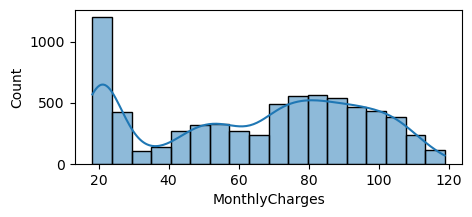

In [72]:
# if data int or float check its distribution
# if it is normal distribution use mean
# else if it has outlier etc use median
# if >0.5 right skewed
# if value<0,5 left skewed
plt.figure(figsize=(5,2))
sns.histplot(data=data,x="MonthlyCharges",kde=True)
plt.show()

In [73]:
data.loc[:,"MonthlyCharges"].skew()

-0.22028439456532767

In [74]:
# hence skew value is - 0.22028 it range in between -0.5 to 0.5 so its normal distribution 
# Hence use mean fillna
data.loc[:,'MonthlyCharges'].mean()

64.74958102542253

In [75]:
# Fillna with mean
data.loc[:,'MonthlyCharges']=data.loc[:,"MonthlyCharges"].fillna(data.loc[:,"MonthlyCharges"].mean())

In [76]:
data.loc[:,"MonthlyCharges"].isnull().sum()

0

In [77]:
# procceed further check for TotalCharges  
# first data type
data.loc[:,"TotalCharges"].dtype

dtype('O')

In [78]:
# convert object data into numeric 
data.loc[:,'Total_Charges'] =pd.to_numeric(data.loc[:,'TotalCharges'],errors='coerce')

In [79]:
data.drop(columns='TotalCharges',inplace=True)

In [80]:
data.loc[:,"Total_Charges"].dtype

dtype('float64')

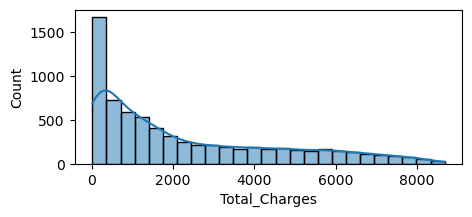

In [81]:
# if data int or float check its distribution
# if it is normal distribution use
# else if it has outlier etc use median
# if >0.5 right skewed
# if value<0,5 left skewed
plt.figure(figsize=(5,2))
sns.histplot(data=data,x="Total_Charges",kde=True)
plt.show()

In [82]:
data.loc[:,"Total_Charges"].skew()

0.9616058347613503

In [83]:
# Right skewed use median
data.loc[:,"Total_Charges"].median()

1397.3

In [84]:
# fillna
data.loc[:,"Total_Charges"]=data.loc[:,"Total_Charges"].fillna(data.loc[:,"Total_Charges"].median())

In [85]:
data.loc[:,"Total_Charges"].isnull().sum()

0

In [86]:
data.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
Churn               0
Total_Charges       0
dtype: int64

In [87]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 
